<a href="https://colab.research.google.com/github/ddoneu/ECON3916-Statistical-Machine-Learning/blob/main/Assignment%203/%20Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1.1: Data Generating Process

In [67]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

#1.2: Manual Boostrap Engine

In [115]:
n_bootstrap = 10000
n = len(driver_tips)
boot_medians = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    resample = driver_tips[np.random.randint(0, n, size=n)]
    boot_medians[i] = np.median(resample)

ci_lower, ci_upper = np.percentile(boot_medians, [2.5, 97.5])

obs_median = np.median(driver_tips)

print('Observed Median:',obs_median)
print('CI Lower:',ci_lower)
print('CI Upper:',ci_upper)
print(f'Asymmetry:\nLower distance: {obs_median-ci_lower:.4f}, Upper distance: {ci_upper-obs_median:.4f}')

Observed Median: 0.7553316913699188
CI Lower: 0.2817246399726829
CI Upper: 1.2990257845869702
Asymmetry:
Lower distance: 0.4736, Upper distance: 0.5437


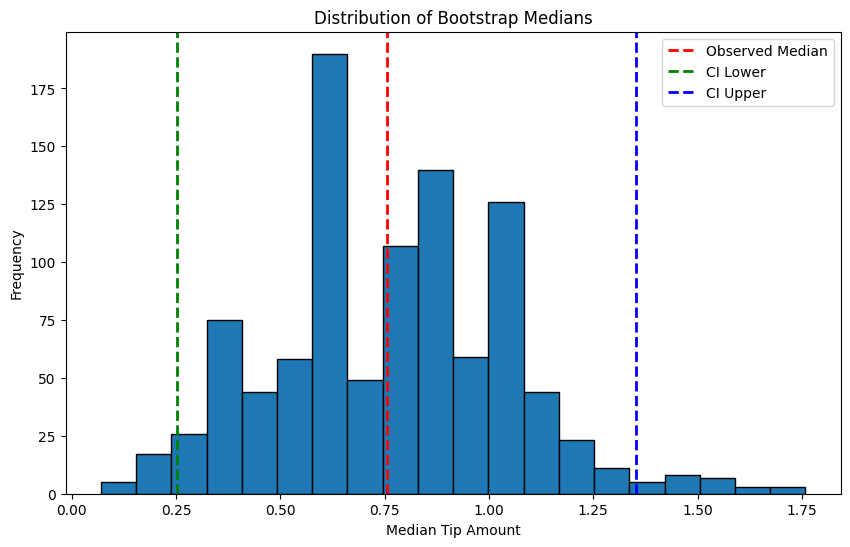

In [69]:
# I add visualization for easier write up about the asymmetry

plt.figure(figsize=(10, 6))
plt.hist(boot_medians, bins=20, edgecolor='black')
plt.axvline(obs_median, color='red', linestyle='--', linewidth=2, label='Observed Median')
plt.axvline(ci_lower, color='green', linestyle='--', linewidth=2, label='CI Lower')
plt.axvline(ci_upper, color='blue', linestyle='--', linewidth=2, label='CI Upper')
plt.title('Distribution of Bootstrap Medians')
plt.xlabel('Median Tip Amount')
plt.ylabel('Frequency')
plt.legend()
plt.show()

The bootstrap CI is asymmetric, the upper bound extends further from the median than the lower bound. This reflects two features of the data: a hard floor at $0 from the zero-inflation (compressing the lower bound) and an unlimited right tail from exponential tips (stretching the upper bound).

A standard parametric CI assumes symmetric uncertainty (±1.96 × SE), which is wrong here. It ignores the skew and could even produce a negative lower bound for the median, economically meaningless for tip data.

#Phase 2

#Step 2.1: The Algorithmic Routing Crash


In [70]:
# Generate synthetic Data:

np.random.seed(42)
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

obs_diff = np.mean(control) - np.mean(treatment)

print(f'Observed Different: {obs_diff:.2f}')

Observed Different: 2.26


#Step 2.2: The Exact Non-Parametric Permutation


In [71]:
n_permutations = 5000
combined = np.concatenate([control, treatment])
permutation_diffs = np.empty(n_permutations)

for i in range(n_permutations):
    shuffled = np.random.permutation(combined)
    permutation_diffs[i] = shuffled[:500].mean() - shuffled[500:].mean()

p_value = np.mean(np.abs(permutation_diffs) >= np.abs(obs_diff))

print(f'Observed difference: {obs_diff:.4f}')
print(f'p-value: {p_value:.4f}')
print('')

if p_value < 0.05:
    print("-> Reject the null hypothesis, statistically significant at a=0.05")
else:
    print("-> Fail to reject the null hypothesis at a=0.05")


Observed difference: 2.2650
p-value: 0.0004

-> Reject the null hypothesis, statistically significant at a=0.05


#Phase 3: Causal Control and the Mitigation of Selection Bias


#Step 3.1: The Loyalty Program Paradox


In [80]:
url = 'https://raw.githubusercontent.com/ddoneu/ECON3916-Statistical-Machine-Learning/refs/heads/main/Data/swiftcart_loyalty.csv'
df = pd.read_csv(url)

df

,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227
...,...,...,...,...,...
8936,1,35.172065,51,0,55.662507
8937,1,83.613898,5,2,94.767676
8938,0,57.146453,6,2,58.616370
8939,0,47.701092,13,0,60.069619


In [94]:
sdo = df[df['subscriber']==1]['post_spend'].mean() - df[df['subscriber']==0]['post_spend'].mean()

print(f'Simple Difference in Means: {sdo:.2f}')
print('')
print(f'Subscriber mean spend: ${df[df['subscriber']==1]['post_spend'].mean():.2f}')
print(f'Non-subscriber mean spend: ${df[df['subscriber']==0]['post_spend'].mean():.2f}')


Simple Difference in Means: 17.57

Subscriber mean spend: $74.04
Non-subscriber mean spend: $56.47


#Step 3.2: Propensity Score Matching (PSM) Architecture


In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [118]:
# Logistic Regression
covariates = ['pre_spend', 'account_age', 'support_tickets']

X = df[covariates]
y = df['subscriber']

logit = LogisticRegression(solver='liblinear')
logit.fit(X, y)
df['pscore'] = logit.predict_proba(X)[:, 1]

print(df.groupby('subscriber')['pscore'].describe().round(4))


             count    mean     std     min     25%     50%     75%     max
subscriber                                                                
0           4741.0  0.4066  0.1688  0.0481  0.2786  0.3973  0.5198  0.9239
1           4200.0  0.5417  0.1709  0.0476  0.4182  0.5474  0.6718  0.9628


In [119]:
# Nearest Neighbors
treated = df[df['subscriber']==1]
control = df[df['subscriber']==0]

nbrs = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(control[['pscore']])

distances, indices = nbrs.kneighbors(treated[['pscore']])
matched_control = control.iloc[indices.flatten()]

matched_df = pd.concat([treated, matched_control])

In [120]:
from scipy import stats

diff = treated['post_spend'].mean() - control['post_spend'].mean()
t_stat, p_val = stats.ttest_ind(treated['post_spend'], control['post_spend'])

print(f"Raw Effect (Difference): ${diff:,.2f}")
print(f"P-value: {p_val:.4f}")
print('')

matched_treated = matched_df[matched_df['subscriber']==1]['post_spend']
matched_control = matched_df[matched_df['subscriber']==0]['post_spend']

matched_diff = matched_treated.mean() - matched_control.mean()
t_stat, p_val = stats.ttest_ind(matched_treated, matched_control)

print(f"Recovered Effect (Matched Difference): ${matched_diff:,.2f}")
print(f"P-value: {p_val:.4f}")

Raw Effect (Difference): $17.57
P-value: 0.0000

Recovered Effect (Matched Difference): $10.14
P-value: 0.0000


The naive SDO of $17.57 overstates the true effect of SwiftPass. High-volume users
self-select into the program, so the naive comparison conflates the program's causal
impact with pre-existing spending differences.

After matching each subscriber to a comparable non-subscriber on pre-treatment
covariates, the true ATT drops to $10.14. The 7.43 gap (42% of the naive SDO)
is pure selection bias. Any budget decision should be based on the ATT, not the
misleading naive figure.

#Phase 4: AI Expansion (The Co-Pilot Era)


#Task 4.1: The "Love Plot" Visualization Directive


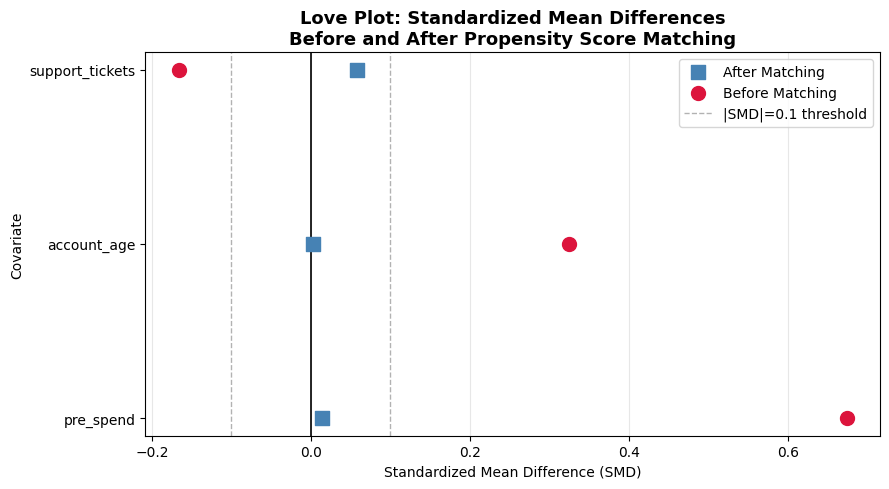


[Love Plot Interpretation]
Post-matching SMDs falling within the |SMD| < 0.1 band (grey dashed lines) indicate
successful covariate balance. Points shifting from red (before) toward zero on blue
(after) confirm the matched sample is now statistically comparable across all
pre-treatment covariates, validating the causal interpretation of the ATT.



In [121]:
def compute_smd(data, covariates, treatment_col):
    records = []
    for cov in covariates:
        t = data[data[treatment_col]==1][cov]
        c = data[data[treatment_col]==0][cov]
        smd = (t.mean() - c.mean()) / np.sqrt((t.var() + c.var()) / 2)
        records.append({'covariate': cov, 'SMD': smd})
    return pd.DataFrame(records)

smd_before = compute_smd(df,         covariates, 'subscriber')
smd_after  = compute_smd(matched_df, covariates, 'subscriber')

smd_before['stage'] = 'Before Matching'
smd_after['stage']  = 'After Matching'
smd_combined = pd.concat([smd_before, smd_after])

fig, ax = plt.subplots(figsize=(9, 5))
colors  = {'Before Matching': 'crimson', 'After Matching': 'steelblue'}
markers = {'Before Matching': 'o',       'After Matching': 's'}

for stage, grp in smd_combined.groupby('stage'):
    ax.scatter(grp['SMD'], grp['covariate'],
               color=colors[stage], marker=markers[stage],
               s=100, zorder=3, label=stage)

ax.axvline(0,    color='black', linewidth=1.2)
ax.axvline(0.1,  color='grey',  linewidth=1, linestyle='--', alpha=0.6, label='|SMD|=0.1 threshold')
ax.axvline(-0.1, color='grey',  linewidth=1, linestyle='--', alpha=0.6)

ax.set_title("Love Plot: Standardized Mean Differences\nBefore and After Propensity Score Matching",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Standardized Mean Difference (SMD)')
ax.set_ylabel('Covariate')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("""
[Love Plot Interpretation]
Post-matching SMDs falling within the |SMD| < 0.1 band (grey dashed lines) indicate
successful covariate balance. Points shifting from red (before) toward zero on blue
(after) confirm the matched sample is now statistically comparable across all
pre-treatment covariates, validating the causal interpretation of the ATT.
""")